# Wykład 3 — część 1: geometria danych, pipeline i regresja

Ta wersja jest świadomie zawężona do materiału **01–16**. Nie ma tu tematów z przyszłości, czyli `17_*`: KNN, drzew, SVM, ensemble ani manifold learning.

Historia części 1:

$$
\text{dane jako punkty} \rightarrow \text{odległości i skala} \rightarrow \text{baseline} \rightarrow \text{regresja liniowa} \rightarrow \text{metryki} \rightarrow \text{pipeline i CV}
$$

Pracujemy głównie na dwóch zbiorach:

- `grades.csv` — mały zbiór do intuicji, tablicy i GeoGebry,
- `tips.csv` — większy zbiór do pipeline'u regresyjnego z cechami liczbowymi i kategorycznymi.

Ważna poprawka z notatek do wykładu: trzeba mocno odróżniać

$$
\hat y \quad \text{predykcja modelu}
$$

od

$$
\bar y \quad \text{średnia / baseline}
$$

To rozróżnienie później bezpośrednio prowadzi do reszt, RSS, TSS i $R^2$.

## Mapa logiczna tej części

Ta część jest zbudowana tak, żeby student stopniowo przechodził od obrazu do wzoru i od wzoru do kodu:

| Krok | Pytanie | Narzędzie |
|---|---|---|
| 1 | Jak widzieć dane? | punkty, wektory, wykres 2D |
| 2 | Jak mierzyć bliskość? | normy, odległości, scaling |
| 3 | Jaki jest najprostszy model? | średnia $\bar y$ |
| 4 | Co robi model liniowy? | predykcja $\hat y$ |
| 5 | Co minimalizujemy? | reszty i $RSS$ |
| 6 | Jak oceniamy poprawę? | $MAE$, $RMSE$, $R^2$ |
| 7 | Jak unikamy przypadkowego wyniku? | train/test, CV, pipeline |

Wykład warto prowadzić tak, żeby po każdej części student umiał wskazać: **co jest obiektem geometrycznym, co jest liczbą, a co jest procedurą walidacji**.

## Jak prowadzić tę część?

Proponowany rytm dydaktyczny jest taki:

1. **intuicja geometryczna** — student widzi dane jako punkty,
2. **mała ręczna tabela** — liczymy coś bez modelu,
3. **kod** — sprawdzamy to samo w Pythonie,
4. **metryka** — opisujemy wynik jedną liczbą,
5. **interpretacja** — co ta liczba znaczy w języku problemu.

Nie zaczynamy od modelu. Zaczynamy od pytania:

$$
\text{co model ma przewidywać i z jakich informacji wolno mu korzystać?}
$$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, log_loss
)

# Notebook może być uruchamiany z różnych katalogów.
# Szukamy plików w ./data, ../data i /mnt/data.
def find_data_file(filename):
    candidates = [
        Path('data') / filename,
        Path('../data') / filename,
        Path(filename),
        Path('/mnt/data') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Nie znaleziono pliku: {filename}')

# Zgodność z różnymi wersjami sklearn: OneHotEncoder zmienił sparse -> sparse_output.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

pd.set_option('display.max_columns', 40)
np.set_printoptions(precision=3, suppress=True)

## 1. Wczytanie danych i szybki audyt

Najpierw bierzemy dwa zbiory:

- `grades` — bardzo mały, ale idealny do tablicy,
- `tips` — większy, dobry do pipeline'u.

Nie budujemy jeszcze modelu. Sprawdzamy, co mamy w danych.

In [2]:
grades_raw = pd.read_csv(find_data_file('previous_lecture_grades.csv'))
tips_raw = pd.read_csv(find_data_file('seaborn_tips.csv'))

grades = grades_raw.dropna(subset=['StudyHours', 'Grade']).copy()
grades['StudyHours'] = grades['StudyHours'].astype(float)
grades['Grade'] = grades['Grade'].astype(float)
grades['Passed'] = (grades['Grade'] >= 50).astype(int)

print('grades shape:', grades.shape)
print('tips shape:', tips_raw.shape)

grades.head()

grades shape: (22, 4)
tips shape: (244, 7)


,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,1
1,Joann,11.50,50.0,1
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0


In [3]:
print('Grades:')
display(grades[['StudyHours', 'Grade', 'Passed']].describe())

print('Tips:')
display(tips_raw.head())

Grades:


,StudyHours,Grade,Passed
count,22.000000,22.000000,22.000000
mean,10.522727,49.181818,0.500000
std,3.487144,21.737912,0.511766
min,1.000000,3.000000,0.000000
25%,9.000000,36.250000,0.000000
50%,10.000000,49.500000,0.500000
75%,12.375000,62.750000,1.000000
max,16.000000,97.000000,1.000000


Tips:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Dane jako punkty i wektory

Każdą obserwację możemy potraktować jako punkt w przestrzeni cech. Dla `grades` najprostszy punkt to:

$$
x_i = (StudyHours_i, Grade_i)
$$

Jeśli później uczymy modelu:

$$
Grade \approx f(StudyHours)
$$

to wykres 2D pozwala zobaczyć, czy w ogóle jest widoczna zależność.

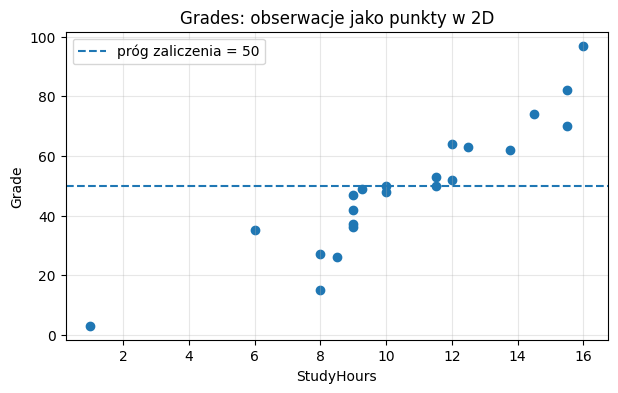

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Grade'])
plt.axhline(50, linestyle='--', label='próg zaliczenia = 50')
plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title('Grades: obserwacje jako punkty w 2D')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Normy i odległości

Norma mierzy długość wektora. Dla wektora

$$
x=(x_1,x_2,\ldots,x_p)
$$

najczęstsze normy to:

$$
\|x\|_2 = \sqrt{x_1^2+x_2^2+\ldots+x_p^2}
$$

$$
\|x\|_1 = |x_1|+|x_2|+\ldots+|x_p|
$$

Odległość między punktami $x$ i $z$ to norma różnicy:

$$
d(x,z)=\|x-z\|
$$

To jest ważne nawet przed KNN/SVM, bo geometria pojawia się już przy resztach, regresji, skalowaniu i regularizacji.

### Przykład interpretacyjny: odległość nie jest neutralna

Załóżmy, że opisujemy studentów dwiema cechami:

$$
x = (StudyHours, PreviousScore)
$$

Odległość euklidesowa mówi, że dwie osoby są podobne, jeśli różnice w obu współrzędnych są małe. Ale to ma sens tylko wtedy, gdy obie cechy są porównywalne albo zostały odpowiednio przeskalowane.

Jeżeli jedna cecha ma zakres od 0 do 100, a druga od 0 do 1, to składnik o większym zakresie może dominować:

$$
(x_1-z_1)^2 \gg (x_2-z_2)^2
$$

Dlatego geometria danych nie jest tylko rysunkiem. To jest ukryte założenie modelowania: **jak definiujemy podobieństwo między obserwacjami**.

In [5]:
# Mini-przykład: trzy osoby opisane wiekiem i dochodem.
people = pd.DataFrame({
    'person': ['A', 'B', 'C'],
    'age': [22, 24, 55],
    'income': [4000, 9000, 9500],
})

X_people = people[['age', 'income']].to_numpy(dtype=float)

# Ręcznie liczymy odległość euklidesową między każdą parą.
def pairwise_euclidean(X):
    D = np.zeros((len(X), len(X)))
    for i in range(len(X)):
        for j in range(len(X)):
            D[i, j] = np.sqrt(np.sum((X[i] - X[j])**2))
    return D

D_raw = pairwise_euclidean(X_people)
pd.DataFrame(D_raw, index=people['person'], columns=people['person'])

person,A,B,C
person,,,
A,0.000000,5000.000400,5500.098999
B,5000.000400,0.000000,500.960078
C,5500.098999,500.960078,0.000000


## 4. Scaling: dlaczego skala zmienia geometrię?

W tabeli `people` cecha `income` ma dużo większy zakres niż `age`. W odległości euklidesowej różnice w dochodzie będą dominować.

StandardScaler zmienia cechę według wzoru:

$$
z = \frac{x-\mu}{\sigma}
$$

MinMaxScaler zmienia cechę do przedziału $[0,1]$:

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

Wykład z GeoGebrą warto prowadzić tak: najpierw pokazujemy punkty w surowej skali, potem przesuwamy/skalujemy osie i pytamy, czy „najbliższy sąsiad” nadal jest ten sam.

In [6]:
standard = StandardScaler()
minmax = MinMaxScaler()

X_standard = standard.fit_transform(X_people)
X_minmax = minmax.fit_transform(X_people)

D_standard = pairwise_euclidean(X_standard)
D_minmax = pairwise_euclidean(X_minmax)

print('Odległości bez skalowania:')
display(pd.DataFrame(D_raw, index=people['person'], columns=people['person']).round(2))

print('Odległości po StandardScaler:')
display(pd.DataFrame(D_standard, index=people['person'], columns=people['person']).round(2))

print('Odległości po MinMaxScaler:')
display(pd.DataFrame(D_minmax, index=people['person'], columns=people['person']).round(2))

Odległości bez skalowania:


person,A,B,C
person,,,
A,0.0,5000.00,5500.10
B,5000.0,0.00,500.96
C,5500.1,500.96,0.00


Odległości po StandardScaler:


person,A,B,C
person,,,
A,0.00,2.02,3.11
B,2.02,0.00,2.06
C,3.11,2.06,0.00


Odległości po MinMaxScaler:


person,A,B,C
person,,,
A,0.00,0.91,1.41
B,0.91,0.00,0.94
C,1.41,0.94,0.00


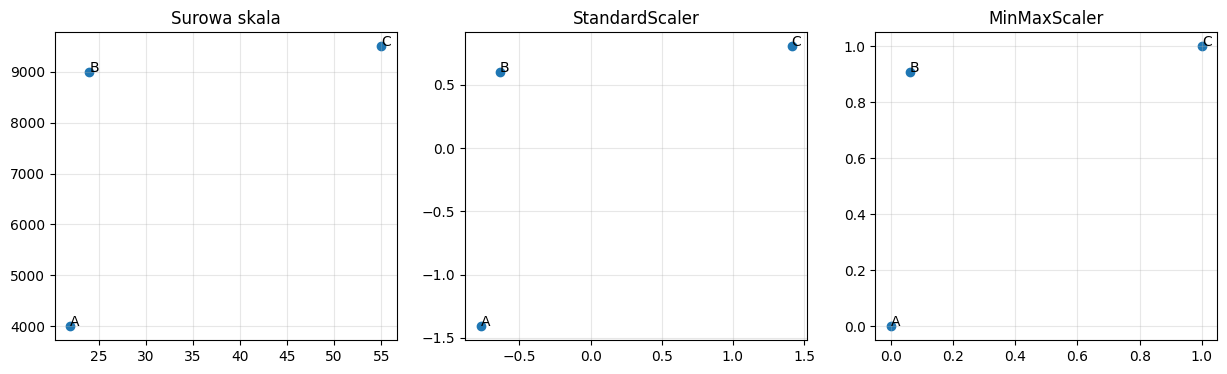

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, X, title in [
    (axes[0], X_people, 'Surowa skala'),
    (axes[1], X_standard, 'StandardScaler'),
    (axes[2], X_minmax, 'MinMaxScaler')
]:
    ax.scatter(X[:, 0], X[:, 1])
    for i, name in enumerate(people['person']):
        ax.annotate(name, (X[i, 0], X[i, 1]))
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.show()

## 5. Cosine similarity: gdy ważniejszy jest kierunek niż długość

Cosine similarity mierzy podobieństwo kierunku:

$$
\cos(x,y)=\frac{x\cdot y}{\|x\|\|y\|}
$$

W zwykłej regresji i pipeline'ach tablicowych częściej używamy skalowania i odległości euklidesowej, ale cosine similarity jest ważne jako intuicja: czasem interesuje nas **profil** wektora, a nie jego długość.

Przykład: dwa dokumenty mogą mieć podobny rozkład słów, nawet jeśli jeden jest znacznie dłuższy.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

profiles = pd.DataFrame({
    'document': ['A', 'B', 'C'],
    'word_ml': [10, 20, 0],
    'word_stats': [8, 16, 5],
    'word_cooking': [0, 0, 12],
})
X_profiles = profiles[['word_ml','word_stats','word_cooking']].to_numpy(dtype=float)
cos = cosine_similarity(X_profiles)
pd.DataFrame(cos, index=profiles['document'], columns=profiles['document']).round(3)

document,A,B,C
document,,,
A,1.00,1.00,0.24
B,1.00,1.00,0.24
C,0.24,0.24,1.00


## 6. Baseline: $\bar y$ jako pierwszy model

Z notatek do wykładu: trzeba mocno odróżnić dwie rzeczy:

$$
\bar y = \text{średnia wartość targetu}
$$

oraz:

$$
\hat y = \text{predykcja modelu}
$$

Baseline regresyjny przewiduje zawsze średnią z train:

$$
\hat y_{baseline}=\bar y_{train}
$$

To jest model zerowy: nie używa cech. Jeśli regresja liniowa nie bije tego baseline'u, nie mamy powodu jej używać.

### Dlaczego $\bar y$ jest modelem, a nie tylko statystyką?

Średnia $\bar y$ bywa traktowana jako opis danych, ale w kontekście modelowania pełni jeszcze jedną rolę: jest predykcją modelu zerowego.

Model zerowy mówi:

$$
\hat y_i = \bar y_{train}
$$

czyli: „nie wiem nic o obserwacji, więc każdemu przewiduję tę samą wartość”. To brzmi naiwnie, ale jest bardzo ważne, bo każdy bardziej skomplikowany model powinien poprawić ten wynik.

W tym sensie regresja liniowa nie jest oceniana w próżni. Pytamy:

$$
\text{czy } \hat y_{model} \text{ jest lepsze niż } \bar y?
$$

To prowadzi bezpośrednio do $R^2$:

$$
R^2 = 1 - \frac{\text{błąd modelu}}{\text{błąd średniej}}
$$

Dlatego rozróżnienie z notatek — $\bar y$ vs $\hat y$ — jest centralne dla całej regresji.

In [9]:
X = grades[['StudyHours']]
y = grades['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Baseline: zawsze przewidujemy średnią ocenę z train.
y_bar_train = y_train.mean()
y_pred_baseline = np.full(shape=len(y_test), fill_value=y_bar_train)

pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'y_baseline_mean_train': y_pred_baseline
}).head()

,y_true,y_baseline_mean_train
0,50.0,56.533333
1,15.0,56.533333
2,26.0,56.533333
3,50.0,56.533333
4,27.0,56.533333


## 7. Regresja liniowa jako dopasowanie prostej

Regresja liniowa w najprostszej wersji zakłada:

$$
\hat y_i = b_0 + b_1 x_i
$$

Tutaj:

$$
\widehat{Grade} = b_0 + b_1 \cdot StudyHours
$$

Model dobiera $b_0$ i $b_1$, aby zminimalizować sumę kwadratów reszt:

$$
RSS = \sum_i (y_i-\hat y_i)^2
$$

GeoGebra świetnie nadaje się do tej części: przesuwamy prostą i widzimy, jak zmieniają się pionowe odległości punktów od prostej.

### Co oznaczają współczynniki prostej?

W modelu:

$$
\widehat{Grade}=b_0+b_1\cdot StudyHours
$$

współczynnik $b_0$ to przewidywana ocena przy $StudyHours=0$. Nie zawsze ma sens praktyczny, ale jest potrzebny matematycznie jako przesunięcie prostej.

Współczynnik $b_1$ mówi, o ile zmienia się predykcja, gdy zwiększamy `StudyHours` o 1:

$$
\Delta \widehat{Grade}=b_1 \quad \text{dla wzrostu StudyHours o 1}
$$

To jest interpretacja lokalna i liniowa. Model zakłada, że przyrost jest taki sam w całym zakresie danych. Dlatego później warto sprawdzać reszty i wykres — bo prosta może być za prostym opisem zjawiska.

In [10]:
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred = lin.predict(X_test)

print(f'Równanie modelu: Grade_hat = {lin.intercept_:.3f} + {lin.coef_[0]:.3f} * StudyHours')

results_reg = pd.DataFrame({
    'model': ['baseline: średnia z train', 'LinearRegression'],
    'MAE': [mean_absolute_error(y_test, y_pred_baseline), mean_absolute_error(y_test, y_pred)],
    'RMSE': [mean_squared_error(y_test, y_pred_baseline)**0.5, mean_squared_error(y_test, y_pred)**0.5],
    'R2': [r2_score(y_test, y_pred_baseline), r2_score(y_test, y_pred)]
})
results_reg

Równanie modelu: Grade_hat = -6.626 + 5.508 * StudyHours


,model,MAE,RMSE,R2
0,baseline: średnia z train,24.952381,30.525222,-1.341419
1,LinearRegression,8.603574,11.205566,0.684478


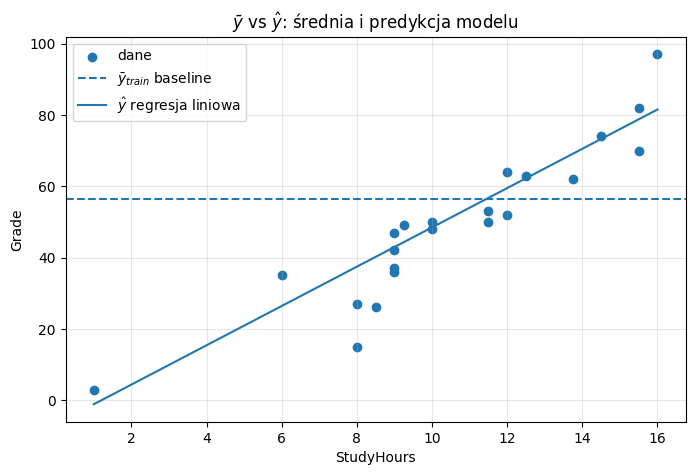

In [11]:
# Wykres: punkty, średnia i prosta regresji.
grid = pd.DataFrame({'StudyHours': np.linspace(grades['StudyHours'].min(), grades['StudyHours'].max(), 200)})
grid['pred'] = lin.predict(grid[['StudyHours']])

plt.figure(figsize=(8, 5))
plt.scatter(grades['StudyHours'], grades['Grade'], label='dane')
plt.axhline(y_bar_train, linestyle='--', label=r'$\bar{y}_{train}$ baseline')
plt.plot(grid['StudyHours'], grid['pred'], label=r'$\hat{y}$ regresja liniowa')
plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title(r'$\bar{y}$ vs $\hat{y}$: średnia i predykcja modelu')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. $R^2$: TSS, RSS, ESS i sens średniej

Rozkład zmienności w regresji liniowej:

$$
TSS = \sum_i (y_i - \bar y)^2
$$

$$
RSS = \sum_i (y_i - \hat y_i)^2
$$

$$
ESS = \sum_i (\hat y_i - \bar y)^2
$$

Dla klasycznej regresji liniowej z interceptem na zbiorze treningowym zachodzi:

$$
TSS = ESS + RSS
$$

Współczynnik determinacji:

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

Interpretacja: ile zmienności względem średniej wyjaśnia model.

### Jak opowiedzieć $TSS$, $RSS$ i $ESS$ na tablicy?

Najprostsza narracja:

1. Najpierw nie mamy modelu, tylko średnią $\bar y$.
2. Każdy punkt ma odległość od średniej: $y_i-\bar y$.
3. Suma kwadratów tych odległości to całkowita zmienność danych:

$$
TSS=\sum_i(y_i-\bar y)^2
$$

4. Potem dopasowujemy model i dostajemy predykcje $\hat y_i$.
5. Teraz każdy punkt ma resztę względem modelu: $y_i-\hat y_i$.
6. Suma kwadratów reszt to niewyjaśniona zmienność:

$$
RSS=\sum_i(y_i-\hat y_i)^2
$$

Jeżeli model jest dobry, $RSS$ jest dużo mniejsze niż $TSS$. Wtedy:

$$
R^2=1-\frac{RSS}{TSS}
$$

jest bliskie 1. Jeśli model nie poprawia średniej, $RSS\approx TSS$ i $R^2\approx 0$.

In [12]:
# Liczymy R2 ręcznie na pełnym zbiorze dla prostoty dydaktycznej.
lin_full = LinearRegression().fit(grades[['StudyHours']], grades['Grade'])
y_hat_full = lin_full.predict(grades[['StudyHours']])
y_true_full = grades['Grade'].to_numpy()
y_bar_full = y_true_full.mean()

TSS = np.sum((y_true_full - y_bar_full)**2)
RSS = np.sum((y_true_full - y_hat_full)**2)
ESS = np.sum((y_hat_full - y_bar_full)**2)
R2_manual = 1 - RSS/TSS

pd.DataFrame([{
    'TSS_total_względem_ybar': TSS,
    'RSS_reszty_modelu': RSS,
    'ESS_wyjaśnione_przez_model': ESS,
    'R2_manual': R2_manual,
    'R2_sklearn': r2_score(y_true_full, y_hat_full)
}]).round(4)

,TSS_total_względem_ybar,RSS_reszty_modelu,ESS_wyjaśnione_przez_model,R2_manual,R2_sklearn
0,9923.2727,1424.8125,8498.4602,0.8564,0.8564


## 9. Design matrix: regresja jako algebra liniowa

Regresję można zapisać macierzowo:

$$
\hat y = X\beta
$$

Dla prostej z interceptem macierz projektu wygląda tak:

$$
X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
$$

Rozwiązanie najmniejszych kwadratów:

$$
\hat\beta = (X^TX)^{-1}X^Ty
$$

To jest ważny most do GLM: wiele modeli zaczyna się od tej samej idei design matrix.

### Design matrix jako most do GLM

Design matrix nie jest tylko sztuczką z algebry liniowej. To wspólny język wielu modeli.

Dla regresji liniowej:

$$
y = X\beta + \epsilon
$$

Dla regresji logistycznej:

$$
logit(p)=X\beta
$$

W obu przypadkach $X$ zawiera kolumny cech, intercept oraz ewentualnie zakodowane kategorie. Różnica polega na tym, co modelujemy:

- w regresji liniowej modelujemy bezpośrednio średnią wartość $y$,
- w regresji logistycznej modelujemy log-odds prawdopodobieństwa klasy 1.

To jest elegancki most między częścią 1 i częścią 2 wykładu.

In [13]:
X_design = np.column_stack([np.ones(len(grades)), grades['StudyHours'].to_numpy()])
y_vec = grades['Grade'].to_numpy()

beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_vec

pd.DataFrame({
    'współczynnik': ['intercept', 'StudyHours'],
    'beta_hat_manual': beta_hat,
    'beta_hat_sklearn': [lin_full.intercept_, lin_full.coef_[0]]
})

,współczynnik,beta_hat_manual,beta_hat_sklearn
0,intercept,-11.522406,-11.522406
1,StudyHours,5.768868,5.768868


## 10. Train/test i cross-validation

Jeden split train/test może być losowo łatwy albo trudny. Cross-validation powtarza ocenę kilka razy.

Dla $K$ foldów:

$$
CV = \frac{1}{K}\sum_{k=1}^{K} score_k
$$

Ważna zasada: jeżeli preprocessing uczy się parametrów, powinien być częścią pipeline'u. Wtedy w każdym foldzie fituje się tylko na treningowej części folda.

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)
cv_scores = cross_val_score(LinearRegression(), grades[['StudyHours']], grades['Grade'], cv=cv, scoring='r2')

pd.DataFrame({
    'fold': np.arange(1, len(cv_scores)+1),
    'R2': cv_scores
}).assign(mean_R2=cv_scores.mean(), std_R2=cv_scores.std()).round(3)

,fold,R2,mean_R2,std_R2
0,1,0.877,0.728,0.123
1,2,0.771,0.728,0.123
2,3,0.540,0.728,0.123
3,4,0.817,0.728,0.123
4,5,0.633,0.728,0.123


## 11. Pipeline regresyjny na `tips`

`tips` jest większym i bardziej realistycznym przykładem. Target:

$$
y = tip
$$

Cechy liczbowe:

$$
total\_bill, size
$$

Cechy kategoryczne:

$$
sex, smoker, day, time
$$

Używamy pipeline'u, żeby oddzielnie przygotować typy kolumn.

### Dlaczego pipeline jest tu ważniejszy niż sam model?

Na `tips` mamy cechy liczbowe i kategoryczne. Gdybyśmy ręcznie przygotowali dane przed splitem, łatwo byłoby popełnić błąd. Pipeline pilnuje kolejności:

$$
\text{split} \rightarrow \text{fit preprocessingu na train} \rightarrow \text{fit modelu na train} \rightarrow \text{ocena na test}
$$

Dla cech liczbowych pipeline liczy medianę i parametry skalowania tylko na train. Dla cech kategorycznych uczy listę kategorii tylko na train. Dopiero potem transformuje test.

To jest praktyczna wersja zasady:

> Test ma udawać przyszłość. Przyszłość nie może wpływać na uczenie.

In [15]:
tips = tips_raw.copy()
X_tips = tips[['total_bill', 'size', 'sex', 'smoker', 'day', 'time']]
y_tips = tips['tip']

num_cols = ['total_bill', 'size']
cat_cols = ['sex', 'smoker', 'day', 'time']

preprocess_reg = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe())
    ]), cat_cols),
])

reg_pipe = Pipeline([
    ('preprocess', preprocess_reg),
    ('model', LinearRegression())
])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tips, y_tips, test_size=0.25, random_state=42
)

reg_pipe.fit(X_train_t, y_train_t)
y_pred_t = reg_pipe.predict(X_test_t)
y_base_t = np.full(len(y_test_t), y_train_t.mean())

pd.DataFrame({
    'model': ['baseline mean', 'LinearRegression pipeline'],
    'MAE': [mean_absolute_error(y_test_t, y_base_t), mean_absolute_error(y_test_t, y_pred_t)],
    'RMSE': [mean_squared_error(y_test_t, y_base_t)**0.5, mean_squared_error(y_test_t, y_pred_t)**0.5],
    'R2': [r2_score(y_test_t, y_base_t), r2_score(y_test_t, y_pred_t)]
}).round(3)

,model,MAE,RMSE,R2
0,baseline mean,1.038,1.198,-0.079
1,LinearRegression pipeline,0.697,0.930,0.350


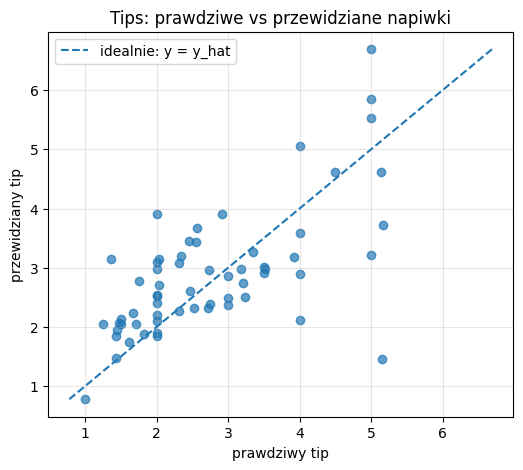

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_t, y_pred_t, alpha=0.7)
lims = [min(y_test_t.min(), y_pred_t.min()), max(y_test_t.max(), y_pred_t.max())]
plt.plot(lims, lims, linestyle='--', label='idealnie: y = y_hat')
plt.xlabel('prawdziwy tip')
plt.ylabel('przewidziany tip')
plt.title('Tips: prawdziwe vs przewidziane napiwki')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Krótka kapsuła: regularyzacja jako kara za zbyt duże współczynniki

Regularyzacja nie jest przyszłym tematem z `17_*`; pojawia się przed mostami aplikacyjnymi. W najprostszej intuicji dodajemy karę do funkcji błędu.

Ridge:

$$
RSS + \lambda \sum_j \beta_j^2
$$

Lasso:

$$
RSS + \lambda \sum_j |\beta_j|
$$

Ridge zmniejsza współczynniki. Lasso może wyzerować część współczynników. To jest kontrola złożoności modelu.

### Regularyzacja geometrycznie

Regularyzację można opowiedzieć jako ograniczenie przestrzeni możliwych współczynników.

Ridge karze sumę kwadratów:

$$
\sum_j\beta_j^2
$$

czyli preferuje małe, gładko rozłożone współczynniki.

Lasso karze sumę wartości bezwzględnych:

$$
\sum_j|\beta_j|
$$

co geometrycznie sprzyja rozwiązaniom, w których część współczynników jest dokładnie równa 0. Dlatego Lasso może działać jak wybór cech.

W tej kompilacji traktujemy regularyzację jako krótki domykający element regresji, nie jako osobny przyszły blok algorytmów.

In [17]:
ridge_pipe = Pipeline([
    ('preprocess', preprocess_reg),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 20)))
])

lasso_pipe = Pipeline([
    ('preprocess', preprocess_reg),
    ('model', LassoCV(alphas=np.logspace(-3, 1, 20), max_iter=10000, random_state=42))
])

models = {'LinearRegression': reg_pipe, 'RidgeCV': ridge_pipe, 'LassoCV': lasso_pipe}
rows = []
for name, model in models.items():
    model.fit(X_train_t, y_train_t)
    pred = model.predict(X_test_t)
    rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_test_t, pred),
        'RMSE': mean_squared_error(y_test_t, pred)**0.5,
        'R2': r2_score(y_test_t, pred)
    })

pd.DataFrame(rows).round(3)

,model,MAE,RMSE,R2
0,LinearRegression,0.697,0.930,0.350
1,RidgeCV,0.689,0.908,0.380
2,LassoCV,0.671,0.854,0.452


## 13. GeoGebra checkpoint

Do tej części pasuje plik:

```text
geogebra/Dopasowanie_prostej_odleglosci_normy_pogladowo.ggb
```

Propozycja użycia na tablicy:

1. pokaż punkty i prostą,
2. przesuń prostą ręcznie,
3. zaznacz pionowe reszty $y_i-\hat y_i$,
4. pokaż średnią $\bar y$ jako baseline,
5. porównaj „odległość do średniej” z „odległością do modelu”,
6. wróć do wzoru $R^2=1-RSS/TSS$.

Najważniejsze zdanie do powiedzenia:

> $\bar y$ jest modelem zerowym, a $\hat y$ jest predykcją modelu. $R^2$ mówi, ile poprawiliśmy względem średniej.

## 14. Checklista po części 1

Student powinien umieć odpowiedzieć:

1. Co oznacza obserwacja jako punkt/wektor?
2. Czym różni się $\bar y$ od $\hat y$?
3. Co to jest reszta $y_i-\hat y_i$?
4. Dlaczego scaling zmienia odległości?
5. Co mierzy MAE, RMSE i $R^2$?
6. Dlaczego baseline jest potrzebny?
7. Po co pipeline i cross-validation?
8. Dlaczego preprocessing nie może być fitowany na test?

To zamyka fundament pod część 2: przejście od regresji do klasyfikacji i log-odds.